# CUSTOMER SEGMENTATION AND REVENUE OPTIMIZATION

## EXECUTIVE SUMMARY
This project analyzes retail transaction data to group customers using RFM and clustering techniques.
The goal is to find  high-value customers and increase revenue by more focused marketing strategies.
- This helps the business understand customer behavior better 
- It also allows the company to make smarter decisions based on data
- It supports improving customer satisfaction and business growth 

## PROBLEM DEFINITION
The company is getting more customers, but its revenue is not increasing at the same rate.<br>
This is happening because all customers are treated the same, without proper grouping.
As a result, marketing efforts are not very effective.<br>
Therefore, the goal is to divide customers into different groups and target them in a better way to improve sales.

## DATASET DESCRIPTION 
The dataset contains retail transactions:
- InvoiceNo   -> transaction ID
- CustomerID  -> unique customer
- Quantity   -> number of items
- UnitPrice  -> price per item
- InvoiceDate-> purchase date 
- Country    -> Customer location<br>
This dataset contains transactional data which allows analysis of customer purchasing behavior over time.


In [1]:
!pip install scikit-learn

## IMPORTING REQUIRED LIBRARIES 
Import the required libraries for data analysis and visualization.


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

## LOAD DATASET 
Load dataset to begin analysis.
This helps to understand customer transactions.

In [3]:
df = pd.read_csv("onlineRetail.csv",encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## MISSING VALUE ANALYSIS 
Check missing values in dataset. This helps to  identify data quality issues

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

CustomerID contains missing values, which are critical for customer-level analysis. Therefore, rows with missing CustomerID are removed to ensure accurate segmentation.

## DATA PREPROCESSING 
Clean and filter invalid values to get better and reliable results  

In [5]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity']>0]
df = df[df['UnitPrice']>0]

Negative and zero values in Quantity and UnitPrice were removed to eliminate invalid transactions.

## ENCODING 
No encoding required, as the dataset already contains numerical features for clustering


## FEATURE ENGINEERING
Create new features for better analysis. This helps calculate revenue and trends clearly 

In [6]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month

## EXPLORATORY DATA ANALYSIS 
Explore data using visualizations.This helps understand patterns and behavior

## UNIVARIATE ANALYSIS 
Analyzing one column at a time 

In [7]:
import pandas as pd
import datetime as dt

# convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# create TotalPrice if not already
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# reference date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# create RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']


print(rfm.head())


            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


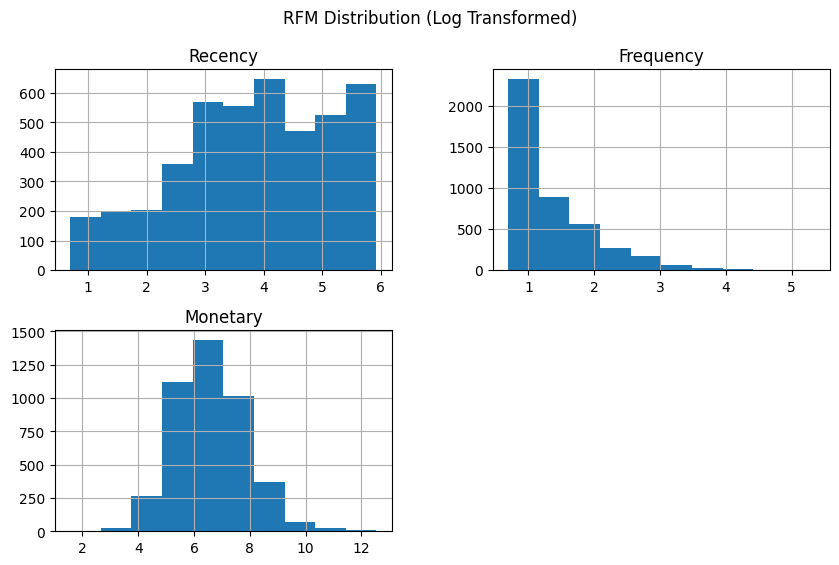

In [8]:
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])
rfm_log[['Recency','Frequency','Monetary']].hist(figsize=(10,6))
plt.suptitle("RFM Distribution (Log Transformed)")
plt.show()

Most customers have low frequency and low spending, while a small number of customers contribute very high revenue, indicating skewed distribution.

## BIVARIATE ANALYSIS
Analyze relationship between variables 

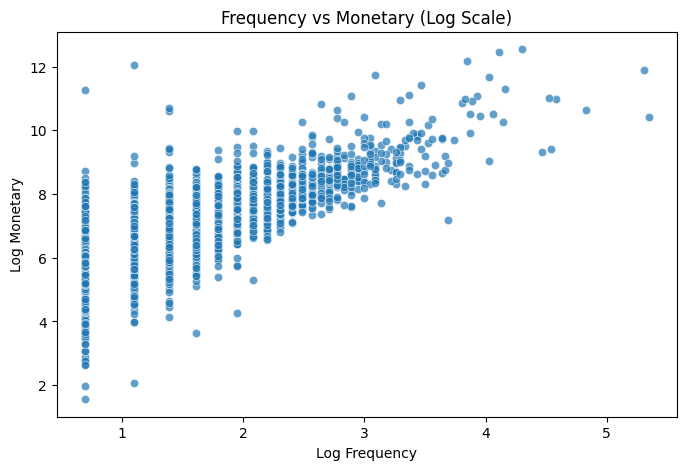

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=np.log1p(rfm['Frequency']),
    y=np.log1p(rfm['Monetary']),
    alpha=0.7
)
plt.title("Frequency vs Monetary (Log Scale)")
plt.xlabel("Log Frequency")
plt.ylabel("Log Monetary")
plt.show()

Customers with higher purchase frequency tend to spend more, indicating a positive relationship between frequency and monetary value.

## CORRELATION ANALYSIS 
Shows relationship between features.

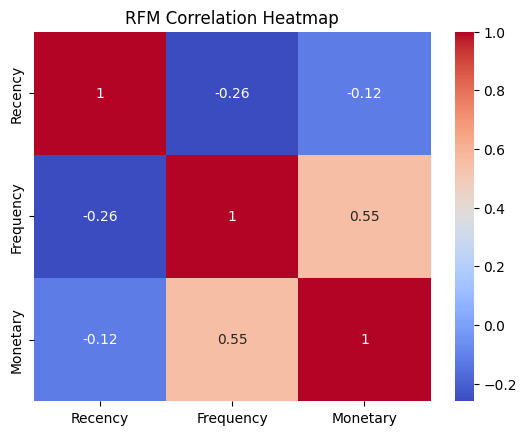

In [10]:
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title("RFM Correlation Heatmap")
plt.show()

Frequency and Monetary show moderate positive correlation, meaning frequent customers tend to spend more.<br>
Recency has a negative correlation with Frequency and Monetary, indicating that customers who purchased recently are more likely to buy frequently and spend more.

## RFM ANALYSIS 
RFM helps evaluate customer value.

In [11]:
import datetime as dt 
# Define reference date (latest transaction date + 1 day)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
     #Recency: Days since last purchase
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    # Frequency: Number of transactions
    'InvoiceNo': 'nunique',
    # Monetary: Total spending
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


- Recency: How recently a customer purchased  
- Frequency: How often a customer buys  
- Monetary: How much money a customer spends  
Customers with recent purchases, frequent buying, and high spending are the most valuable.

## SCALING 
Scaling makes all features equal, Which helps improve clustering results.

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

## MODEL BUILDING 
Clustering helps divide customers into groups.Using more than one model improves accuracy 

K-Means clustering was chosen due to its efficiency and suitability for large datasets.

In [13]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

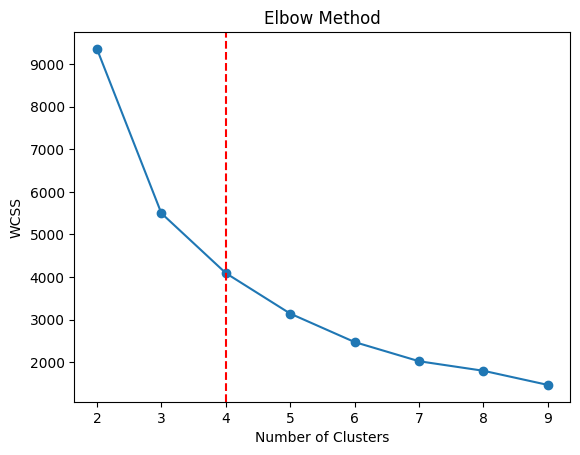

In [14]:
# Elbow Method to find optimal number of clusters
wcss = []
for i in range(2,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
    
# Plot WCSS vs number of clusters
plt.plot(range(2,10), wcss, marker='o')
plt.axvline(x=4, color='r', linestyle='--') 
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The Elbow Method shows that the optimal number of clusters is 4, as the rate of decrease in WCSS slows down after this point.

In [15]:
from sklearn.cluster import KMeans 
kmeans = KMeans(n_clusters=4,random_state=42) 
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

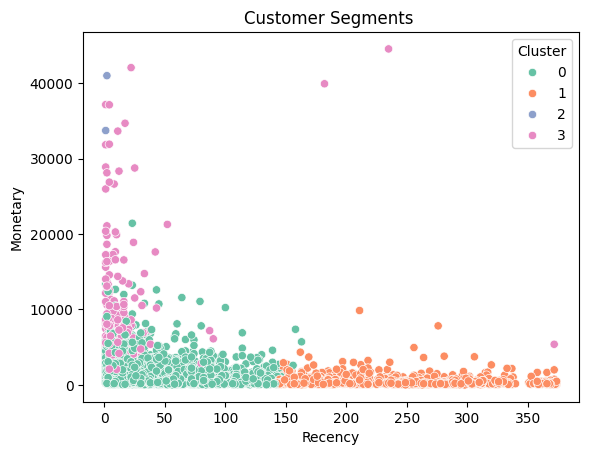

In [16]:
rfm_filtered = rfm[(rfm['Monetary'] < 50000) & (rfm['Frequency'] < 1000)]

# Scatter plot to visualize customer segments
sns.scatterplot(
    x=rfm_filtered['Recency'],
    y=rfm_filtered['Monetary'],
    hue=rfm_filtered['Cluster'],
    palette='Set2'
)
plt.title("Customer Segments ")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

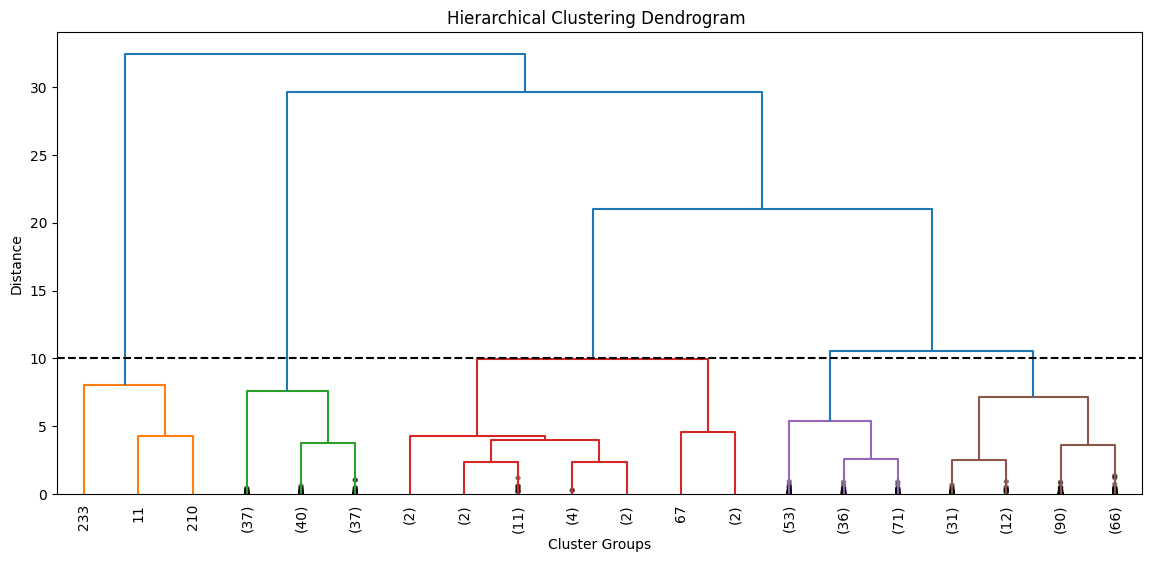

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Take a sample of data (for faster computation)
np.random.seed(42)
idx = np.random.choice(len(rfm_scaled), size=500, replace=False)
rfm_sample = rfm_scaled[idx]
linked = linkage(rfm_sample, method='ward')
plt.figure(figsize=(14,6))
dendrogram(
    linked,
    truncate_mode='lastp',   
    p=20,                   
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=10      
)
plt.axhline(y=10, color='black', linestyle='--')  
plt.title("Hierarchical Clustering Dendrogram ")
plt.xlabel("Cluster Groups")
plt.ylabel("Distance")
plt.show()

## Model Comparison

Both K-Means and Hierarchical clustering were applied to segment customers.

K-Means provided more distinct and well-separated clusters, making it easier to interpret customer groups.

Hierarchical clustering helped visualize cluster structure but was less scalable for large datasets.

Therefore, K-Means was selected as the final model for customer segmentation.

## EVALUATION 
Use silhouette score to check how well the data is grouped.A higher score means better clustering 

In [18]:
from sklearn.metrics import silhouette_score
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(score)

0.616212846765192


A silhouette score of 0.61 indicates that the clusters are well-separated and distinct.
This confirms that the K-Means model has effectively grouped customers based on their purchasing behavior.

## Visualization
Visualize customer segements,
This helps understand cluster differences

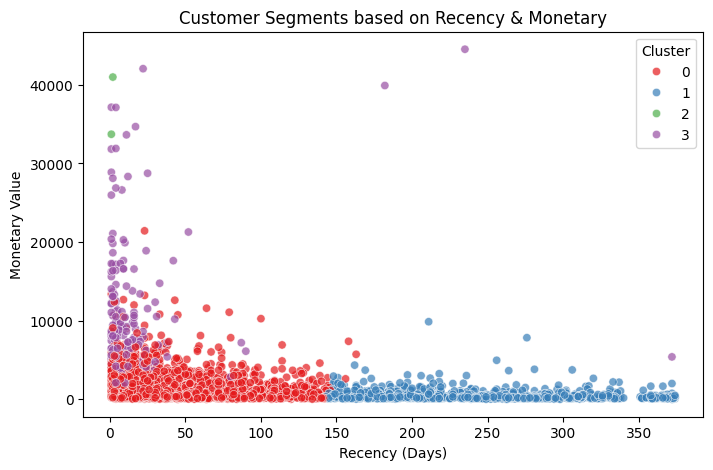

In [19]:
plt.figure(figsize=(8,5))
rfm_filtered = rfm[
    (rfm['Monetary'] < 50000) & 
    (rfm['Frequency'] < 1000)
]
sns.scatterplot(
    data=rfm_filtered,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    alpha=0.7
)
plt.title("Customer Segments based on Recency & Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title='Cluster')
plt.show()

This plot visualizes customer segments based on Recency and Monetary values. Customers on the left are recent buyers, while those at the top have higher spending. Different colors represent different customer segments.

## Cluster Profiling
Analyze cluster averages.  
This helps define customer types.

In [20]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


Cluster 0 – Regular Customers:
Moderate recency, low frequency, and moderate spending.

Cluster 1 – At-Risk Customers:
Very high recency, very low frequency, and low spending. These customers are likely inactive.

Cluster 2 – VIP Customers:
Very low recency, extremely high frequency, and extremely high spending. These are the most valuable customers.

Cluster 3 – High-Value Customers:
Low recency, good frequency, and high spending. These customers are active and valuable.

## INSIGHTS 
A small group of customers contributes a large portion of total revenue.<br>
VIP customers are highly valuable and should be prioritized for retention.<br>
Some customers show low engagement and are at risk of churn.<br>
Customer behavior varies significantly, highlighting the need for segmentation.<br>

## BUSINESS RECOMMENDATIONS
Provide exclusive rewards, loyalty programs, and personalized offers to VIP and high-value customers to improve retention.<br>
Re-engage at-risk customers through targeted discounts, email campaigns, and special promotions.<br>
Encourage regular customers to increase purchase frequency using bundled offers and limited-time deals.<br>
Focus marketing efforts on high-value segments to maximize return on investment and revenue growth.

## Limitations
K-Means requires predefined number of clusters.<br>
The model does not consider time-based behavior changes<br>
Outliers may affect clustering results.

## CONCLUSION 
Customer segmentation using RFM and clustering techniques enables the identification of distinct customer groups based on purchasing behavior.<br>
This approach supports targeted marketing strategies, improves customer retention, and increases overall revenue.<br>
By leveraging data-driven insights, businesses can optimize decision-making and enhance long-term growth.<br>

In [21]:
rfm.to_csv("rfm_processed.csv")